In [1]:
#importing the Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv("insurance_pre.csv")
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [3]:
dataset=pd.get_dummies(dataset, drop_first=True)
dataset=dataset.astype(int)

In [4]:
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27,0,16884,0,1
1,18,33,1,1725,1,0
2,28,33,3,4449,1,0
3,33,22,0,21984,1,0
4,32,28,0,3866,1,0
...,...,...,...,...,...,...
1333,50,30,3,10600,1,0
1334,18,31,0,2205,0,0
1335,18,36,0,1629,0,0
1336,21,25,0,2007,0,0


In [5]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [6]:
independent=dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]
independent

,age,bmi,children,sex_male,smoker_yes
0,19,27,0,0,1
1,18,33,1,1,0
2,28,33,3,1,0
3,33,22,0,1,0
4,32,28,0,1,0
...,...,...,...,...,...
1333,50,30,3,1,0
1334,18,31,0,0,0
1335,18,36,0,0,0
1336,21,25,0,0,0


In [7]:
dependent=dataset[['charges']]
dependent

,charges
0,16884
1,1725
2,4449
3,21984
4,3866
...,...
1333,10600
1334,2205
1335,1629
1336,2007


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(independent, dependent, test_size=0.20, random_state=0)

In [9]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor=regressor.fit(X_train,Y_train)

In [10]:
Y_pred=regressor.predict(X_test)

In [11]:
Y_pred

array([10072.        ,  8930.        , 44202.        , 13143.        ,
        9264.        , 21984.        ,  1615.        , 10381.        ,
        7151.        ,  4837.        ,  4766.        , 30284.        ,
       32108.        ,  4571.        , 16577.        , 10264.        ,
       12629.        ,  3292.        ,  6455.        , 33750.        ,
       24869.        , 13224.        , 10797.        , 21774.        ,
        1391.        ,  3875.        ,  2680.        ,  7209.        ,
        3757.        ,  8520.        ,  7201.        , 47896.        ,
       13981.        , 10226.        , 15359.        ,  3554.        ,
        8733.        , 37133.        , 39836.        ,  1880.        ,
       21984.        ,  2866.        , 21082.        , 43813.        ,
       36219.        ,  3579.        , 30284.        ,  6389.        ,
        4719.        , 12032.        ,  2664.        , 22493.        ,
       28868.        , 60021.        , 11856.        , 19673.        ,
      

In [12]:
from sklearn.metrics import r2_score
r_score=r2_score(Y_test, Y_pred)
r_score

0.7071299677459021

In [13]:
regressor.feature_importances_

array([0.14800899, 0.20509383, 0.03033678, 0.00738064, 0.60917976])

In [14]:
regressor.max_features_

5

In [15]:
regressor.tree_

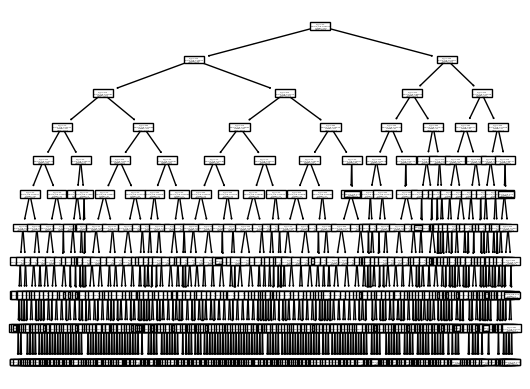

In [50]:
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [17]:
rd_input=float(input("age:"))
admin_input=float(input("sex"))
mark_input=float(input("bmi "))
fol_input=int(input("children:"))
new_input=int(input("Smoker 0 or 1:"))

age: 12
sex 1
bmi  29
children: 0
Smoker 0 or 1: 0


In [19]:
result=regressor.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])

C:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [20]:
result

array([11884.])

In [ ]:
# Different hypertuning parameters

In [47]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion="absolute_error", splitter="best",max_depth=10 )
regressor=regressor.fit(X_train,Y_train)

In [48]:
Y_pred=regressor.predict(X_test)

In [49]:
r_score=r2_score(Y_test, Y_pred)
r_score

0.776507124811011